# Bike Sharing Dataset — Data Analysis Project

## Business Questions

- How has the number of bike rentals trended over time?
- How do casual and registered users compare in total rentals?
- How does rental behavior differ between weekdays and weekends?
- How does rental behavior differ across seasons?
- What are the peak rental hours, and how do they differ between weekdays and weekends?
- How can days be segmented by rental volume to identify high-value and low-activity periods? (Temporal RFM)

## Import Libraries

In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Color palette (consistent with dashboard) ──
BASE_COLOR      = "#4A90D9"   # blue  — base color for all bars
HIGHLIGHT_COLOR = "#E07B39"   # orange — highlights the bar with the highest value

def get_bar_colors(counts):
    """Return color list: highlight for max value, base color for the rest."""
    max_val = max(counts) if counts else 0
    return [HIGHLIGHT_COLOR if v == max_val else BASE_COLOR for v in counts]

def add_bar_annotations(ax, counts, fontsize=12):
    """Add value labels above each bar."""
    for i, v in enumerate(counts):
        ax.text(
            i, v + max(counts) * 0.01,
            f"{int(v):,}",
            ha='center', va='bottom',
            fontsize=fontsize, fontweight='bold'
        )

sns.set(style='dark')

## Data Wrangling

### Gathering Data

In [156]:
hour_df = pd.read_csv("data\\hour.csv")
hour_df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17374,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
17375,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
17376,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90
17377,17378,2012-12-31,1,1,12,22,0,1,1,1,0.26,0.2727,0.56,0.1343,13,48,61


**Insight:**
This table contains 17,379 rows with hourly bike rental information.

### Assessing Data

In [157]:
# Check data types
hour_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.4 MB


**Insight:** The `dteday` column has an incorrect data type — it should be `datetime` since it represents dates in `yyyy-mm-dd` format. All other columns appear to be correct.

In [158]:
# Check for duplicate rows
hour_df.duplicated().sum()

np.int64(0)

**Insight:** No duplicate rows found in the dataset.

In [159]:
# Check for missing values
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**Insight:** No missing values found in the dataset.

In [160]:
# Check statistical parameters
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:** Statistical summary shows no anomalies in the dataset.

### Cleaning Data

In [161]:
# Convert 'dteday' column to datetime
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
hour_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[us]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

**Insight:** The `dteday` column has been successfully converted to `datetime` format.

In [162]:
# Re-check missing values after type conversion
hour_df.isna().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

**Insight:** No missing values introduced during the type conversion.

## Exploratory Data Analysis (EDA)

### Exploring casual vs registered users and rental trends over time

In [163]:
# Summary statistics
hour_df.describe()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


**Insight:** Based on the summary above:
- Casual rentals per hour range from 0 to 367; registered rentals range from 0 to 886.
- Total hourly rentals range from 1 to 977.

In [164]:
# Total casual vs registered users
casual_sum     = hour_df['casual'].sum()
registered_sum = hour_df['registered'].sum()

print(f"Total Casual Users:     {casual_sum:,}")
print(f"Total Registered Users: {registered_sum:,}")

Total Casual Users:     620,017
Total Registered Users: 2,672,662


**Insight:** Registered users (2,672,662) significantly outnumber casual users (620,017), showing a strong base of loyal, repeat customers.

In [165]:
# Rental trend over time (grouped by year and month)
total_rental = hour_df.groupby(by=["yr", "mnth"]).agg({
    "casual":     "sum",
    "registered": "sum",
    "cnt":        "sum"
})
total_rental.sort_values(by="cnt", ascending=False)

casual  registered     cnt
yr mnth                            
1  9      43778      174795  218573
   8      43197      171306  214503
   7      41705      161902  203607
   6      43294      159536  202830
   10     34538      164303  198841
   5      44235      151630  195865
   4      38456      135768  174224
   3      31618      133257  164875
   11     21009      131655  152664
0  6      30612      112900  143512
   7      36452      104889  141341
   8      28842      107849  136691
   5      31050      104771  135821
   9      26545      100873  127418
1  12     13245      110468  123713
0  10     25222       98289  123511
1  2       8721       94416  103137
0  11     15594       86573  102167
1  1       8969       87775   96744
0  4      22346       72524   94870
   12      8448       78875   87323
   3      12826       51219   64045
   2       6242       41973   48215
   1       3073       35116   38189

**Insight:**
- In 2012, the peak month was September (218,573 rentals); the lowest was January (96,744).
- In 2011, the peak was June (143,512 rentals); the lowest was also January (38,189).

### Exploring rental behavior: Weekday vs Weekend

In [166]:
# Create 'is_workingday' column with English labels
hour_df["is_workingday"] = hour_df["workingday"].apply(
    lambda x: "Weekday" if x == 1 else "Weekend"
)
hour_df[["workingday", "is_workingday"]].head()

,workingday,is_workingday
0,0,Weekend
1,0,Weekend
2,0,Weekend
3,0,Weekend
4,0,Weekend


In [167]:
# Group by day type and year
weekday_rental = hour_df.groupby(by=["is_workingday", "yr"]).agg({
    'casual':     'sum',
    'registered': 'sum',
    'cnt':        'sum'
})

print("Bike rentals by day type:")
display(weekday_rental)

Bike rentals by day type:


casual  registered      cnt
is_workingday yr                             
Weekday       0   118354      737910   856264
              1   184931     1251215  1436146
Weekend       0   128898      257941   386839
              1   187834      425596   613430

**Insight:** Rentals are consistently higher on weekdays than weekends.
- 2011: Weekday 613,430 vs Weekend 386,839
- 2012: Weekday 1,436,146 vs Weekend 856,264

This suggests many users rely on bike-sharing for their daily commute.

### Exploring rental behavior across seasons

In [168]:
# Map season codes to English labels
season_mapping = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}
hour_df["season_category"] = hour_df["season"].map(season_mapping)
hour_df[["season", "season_category"]].head()

,season,season_category
0,1,Spring
1,1,Spring
2,1,Spring
3,1,Spring
4,1,Spring


In [169]:
# Group by season
rental_by_season = hour_df.groupby('season_category').agg({
    'casual':     'sum',
    'registered': 'sum',
    'cnt':        'sum'
})

print("Bike rentals by season:")
display(rental_by_season.sort_values(by='cnt', ascending=False))

Bike rentals by season:


,casual,registered,cnt
season_category,,,
Fall,226091,835038,1061129
Summer,203522,715067,918589
Winter,129782,711831,841613
Spring,60622,410726,471348


**Insight:** Fall has the highest total rentals, while Spring has the lowest. Users prefer mild, comfortable weather over extreme cold or heat.

### Exploring the effect of weather and temperature on rental behavior

In [170]:
# Bin temperature into 5 categories
hour_df['temp_category'] = pd.cut(
    hour_df['temp'], bins=5,
    labels=['Very Cold', 'Cold', 'Mild', 'Warm', 'Hot']
)

# Group by weather condition and temperature category
rental_by_cond = hour_df.groupby(by=["weathersit", "temp_category"]).agg({
    'casual':     'sum',
    'registered': 'sum',
    'cnt':        'sum',
    'temp':       'mean',
    'hum':        'mean',
    'windspeed':  'mean'
})

print("Bike rentals by weather condition and temperature:")
display(rental_by_cond.sort_values(by="cnt", ascending=False))

Bike rentals by weather condition and temperature:


casual  registered     cnt      temp       hum  \
weathersit temp_category                                                   
1          Warm           226199      762071  988270  0.698895  0.598774   
           Mild           134059      549446  683505  0.510425  0.596150   
           Cold            47046      364680  411726  0.310892  0.563098   
2          Warm            62026      226462  288488  0.685295  0.692125   
           Mild            42935      214197  257132  0.513394  0.743590   
           Cold            23126      186394  209520  0.319246  0.686713   
1          Hot             53158      153559  206717  0.860567  0.408583   
3          Warm            11412       48154   59566  0.663510  0.799636   
           Mild             7388       48107   55495  0.511507  0.848121   
1          Very Cold        2283       45672   47955  0.156522  0.541851   
3          Cold             3472       34515   37987  0.319650  0.826000   
2          Hot              5369       17197   22566  0.848615  0.459538   
           Very Cold        1025       17221   18246  0.169963  0.620879   
3          Very Cold         153        3083    3236  0.170732  0.849756   
           Hot               358        1689    2047  0.851111  0.495556   
4          Very Cold           7         180     187  0.170000  0.860000   
           Cold                1          35      36  0.220000  0.930000   

                          windspeed  
weathersit temp_category             
1          Warm            0.178559  
           Mild            0.192428  
           Cold            0.197879  
2          Warm            0.172428  
           Mild            0.184331  
           Cold            0.181840  
1          Hot             0.206536  
3          Warm            0.213506  
           Mild            0.221137  
1          Very Cold       0.195773  
3          Cold            0.226174  
2          Hot             0.206431  
           Very Cold       0.172769  
3          Very Cold       0.174200  
           Hot             0.252067  
4          Very Cold       0.141800  
           Cold            0.328400

**Insight:**
- Rentals peak under clear weather with warm temperatures, normal humidity, and low wind speed.
- Rentals drop sharply in extreme conditions — heavy rain, storms, or very cold weather.

### Exploring the effect of weather and temperature on rental behavior

In [171]:
# Bin temperature into 5 categories
hour_df['temp_category'] = pd.cut(
    hour_df['temp'], bins=5,
    labels=['Very Cold', 'Cold', 'Mild', 'Warm', 'Hot']
)

# Group by weather condition and temperature category
rental_by_cond = hour_df.groupby(by=["weathersit", "temp_category"]).agg({
    'casual':     'sum',
    'registered': 'sum',
    'cnt':        'sum',
    'temp':       'mean',
    'hum':        'mean',
    'windspeed':  'mean'
})

print("Bike rentals by weather condition and temperature:")
display(rental_by_cond.sort_values(by="cnt", ascending=False))

Bike rentals by weather condition and temperature:


casual  registered     cnt      temp       hum  \
weathersit temp_category                                                   
1          Warm           226199      762071  988270  0.698895  0.598774   
           Mild           134059      549446  683505  0.510425  0.596150   
           Cold            47046      364680  411726  0.310892  0.563098   
2          Warm            62026      226462  288488  0.685295  0.692125   
           Mild            42935      214197  257132  0.513394  0.743590   
           Cold            23126      186394  209520  0.319246  0.686713   
1          Hot             53158      153559  206717  0.860567  0.408583   
3          Warm            11412       48154   59566  0.663510  0.799636   
           Mild             7388       48107   55495  0.511507  0.848121   
1          Very Cold        2283       45672   47955  0.156522  0.541851   
3          Cold             3472       34515   37987  0.319650  0.826000   
2          Hot              5369       17197   22566  0.848615  0.459538   
           Very Cold        1025       17221   18246  0.169963  0.620879   
3          Very Cold         153        3083    3236  0.170732  0.849756   
           Hot               358        1689    2047  0.851111  0.495556   
4          Very Cold           7         180     187  0.170000  0.860000   
           Cold                1          35      36  0.220000  0.930000   

                          windspeed  
weathersit temp_category             
1          Warm            0.178559  
           Mild            0.192428  
           Cold            0.197879  
2          Warm            0.172428  
           Mild            0.184331  
           Cold            0.181840  
1          Hot             0.206536  
3          Warm            0.213506  
           Mild            0.221137  
1          Very Cold       0.195773  
3          Cold            0.226174  
2          Hot             0.206431  
           Very Cold       0.172769  
3          Very Cold       0.174200  
           Hot             0.252067  
4          Very Cold       0.141800  
           Cold            0.328400

**Insight:**
- Rentals peak under clear weather with warm temperatures, normal humidity, and low wind speed.
- Rentals drop sharply in extreme conditions — heavy rain, storms, or very cold weather.

### Exploring rental behavior by time of day

In [172]:
# Segment hours into meaningful time-of-day categories
def assign_time_segment(hr):
    if hr <= 5:                return 'Late Night'
    elif hr <= 9:              return 'Morning Rush Hour'
    elif hr <= 15:             return 'Midday'
    elif hr <= 19:             return 'Evening Rush Hour'
    else:                      return 'Night'

hour_df['time_segment'] = hour_df['hr'].apply(assign_time_segment)

# Define display order
TIME_ORDER = ['Late Night', 'Morning Rush Hour', 'Midday', 'Evening Rush Hour', 'Night']

# Aggregate by time segment
rental_by_time = hour_df.groupby('time_segment').agg({
    'casual':     'sum',
    'registered': 'sum',
    'cnt':        'sum'
}).reindex(TIME_ORDER)

print('Rentals by time segment:')
display(rental_by_time)

Rentals by time segment:


,casual,registered,cnt
time_segment,,,
Late Night,19275,87234,106509
Morning Rush Hour,49273,580469,629742
Midday,289201,716510,1005711
Evening Rush Hour,188055,913114,1101169
Night,74213,375335,449548


**Insight:**
- Evening Rush Hour (16:00–19:00) and Morning Rush Hour (06:00–09:00) record the highest volumes — strongly suggesting commuter-driven demand.
- Registered users dominate during both rush hours, while casual users are more active during Midday and Evening.
- Late Night sees very little activity from either user type.

In [173]:
# Average hourly rentals: weekday vs weekend
avg_by_hour = hour_df.groupby(['hr', 'is_workingday'])['cnt'].mean().reset_index()
print('Average rentals per hour (Weekday vs Weekend):')
display(avg_by_hour.pivot(index='hr', columns='is_workingday', values='cnt').round(1))

Average rentals per hour (Weekday vs Weekend):


is_workingday,Weekday,Weekend
hr,,
0,36.8,90.8
1,16.6,69.5
2,8.7,53.2
3,4.9,25.8
4,5.4,8.3
5,24.9,8.7
6,102.5,18.7
7,290.6,43.4
8,477.0,105.7


**Insight:**
- On weekdays, there are two clear peaks: ~08:00 and ~17:00–18:00, driven by registered commuters.
- On weekends, rentals rise gradually through the morning and plateau from ~11:00–15:00, reflecting leisure usage.
- This bimodal vs. unimodal pattern is a strong indicator of different user motivations on each day type.

### Exploring daily rental volume patterns (RFM Foundation)

In [174]:
# Aggregate hourly data to daily totals
daily_df = hour_df.groupby('dteday').agg({
    'casual':          'sum',
    'registered':      'sum',
    'cnt':             'sum',
    'mnth':            'first',
    'yr':              'first',
    'weekday':         'first',
    'season_category': 'first',
    'is_workingday':   'first'
}).reset_index()

# ── M: Magnitude — daily volume segmentation ──
p33 = daily_df['cnt'].quantile(0.33)
p66 = daily_df['cnt'].quantile(0.66)
print(f'33rd percentile (Low/Medium threshold): {p33:,.0f}')
print(f'66th percentile (Medium/High threshold): {p66:,.0f}')

daily_df['magnitude'] = pd.cut(
    daily_df['cnt'],
    bins=[-float('inf'), p33, p66, float('inf')],
    labels=['Low', 'Medium', 'High']
)

print('\nDaily volume distribution by Magnitude:')
display(daily_df['magnitude'].value_counts().sort_index())

33rd percentile (Low/Medium threshold): 3,716
66th percentile (Medium/High threshold): 5,266

Daily volume distribution by Magnitude:


magnitude
Low       241
Medium    241
High      249
Name: count, dtype: int64

**Insight:** Daily rentals span a wide range. Using the 33rd and 66th percentiles as thresholds, days are segmented into Low, Medium, and High volume groups — forming the Magnitude (M) dimension of the RFM model.

In [175]:
# Monthly rental frequency (F dimension foundation)
monthly_freq = daily_df.groupby(['yr', 'mnth'])['cnt'].agg(['sum', 'count', 'mean']).reset_index()
monthly_freq.columns = ['Year', 'Month', 'Total Rentals', 'Days', 'Avg Daily Rentals']
monthly_freq['Avg Daily Rentals'] = monthly_freq['Avg Daily Rentals'].round(0).astype(int)
print('Monthly rental frequency summary:')
display(monthly_freq)

Monthly rental frequency summary:


,Year,Month,Total Rentals,Days,Avg Daily Rentals
0,0,1,38189,31,1232
1,0,2,48215,28,1722
2,0,3,64045,31,2066
3,0,4,94870,30,3162
4,0,5,135821,31,4381
5,0,6,143512,30,4784
6,0,7,141341,31,4559
7,0,8,136691,31,4409
8,0,9,127418,30,4247
9,0,10,123511,31,3984


**Insight:** Monthly totals vary significantly — from quiet winter months to peak fall periods. This monthly total becomes the Frequency (F) dimension: months with higher totals indicate higher-frequency rental periods.

## Visualization & Explanatory Analysis

### Question 1: How has bike rental performance trended over time?

In [176]:
# Resample to monthly totals
monthly_rentals = hour_df.resample(rule='ME', on='dteday').agg({
    'cnt': 'sum'
}).reset_index()

monthly_rentals['year']  = monthly_rentals['dteday'].dt.year
monthly_rentals['month'] = monthly_rentals['dteday'].dt.strftime('%B')

monthly_rentals.head()

,dteday,cnt,year,month
0,2011-01-31,38189,2011,January
1,2011-02-28,48215,2011,February
2,2011-03-31,64045,2011,March
3,2011-04-30,94870,2011,April
4,2011-05-31,135821,2011,May


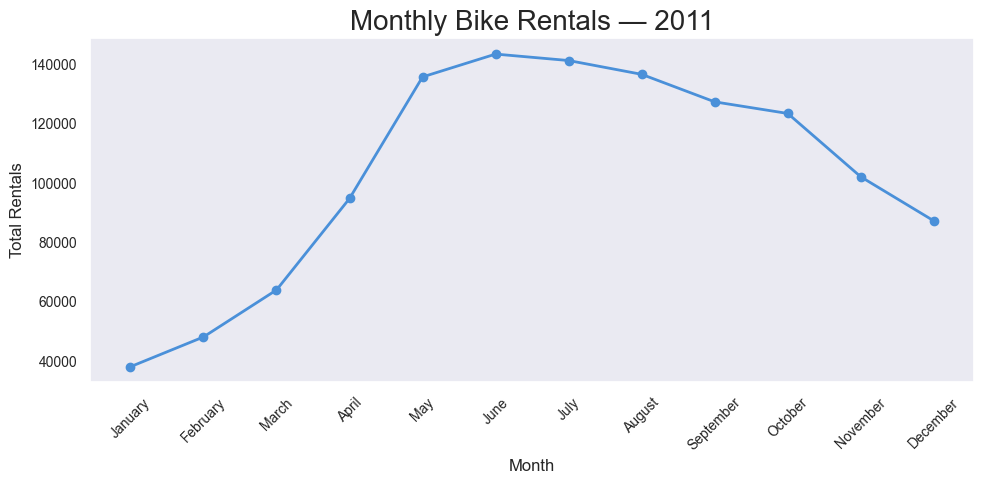

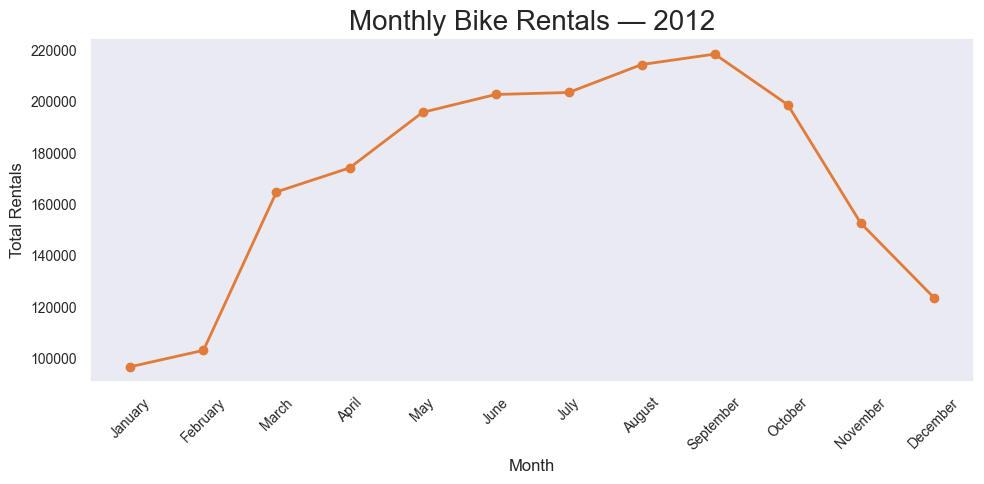

In [177]:
monthly_rentals_2011 = monthly_rentals[monthly_rentals['year'] == 2011]
monthly_rentals_2012 = monthly_rentals[monthly_rentals['year'] == 2012]

# 2011
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_rentals_2011['month'], monthly_rentals_2011['cnt'],
    marker='o', linewidth=2, color=BASE_COLOR
)
plt.title('Monthly Bike Rentals — 2011', loc='center', fontsize=20)
plt.xlabel('Month')
plt.ylabel('Total Rentals')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# 2012
plt.figure(figsize=(10, 5))
plt.plot(
    monthly_rentals_2012['month'], monthly_rentals_2012['cnt'],
    marker='o', linewidth=2, color=HIGHLIGHT_COLOR
)
plt.title('Monthly Bike Rentals — 2012', loc='center', fontsize=20)
plt.xlabel('Month')
plt.ylabel('Total Rentals')
plt.xticks(rotation=45, fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

**Insight:** Rentals show a clear seasonal pattern in both years — rising toward mid-year and declining toward year-end. In 2012, the peak month shifted to September–October, with overall volumes significantly higher than 2011, indicating strong year-over-year growth.

### Question 2: How do casual and registered users compare in total rentals?

C:\Users\slyth\AppData\Local\Temp\ipykernel_12824\3216915006.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=colors)


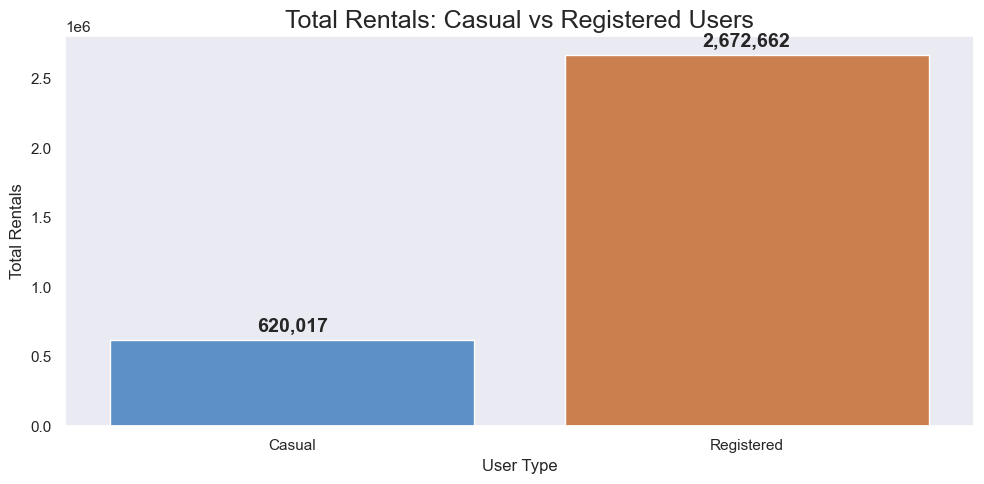

In [178]:
labels = ['Casual', 'Registered']
counts = [hour_df['casual'].sum(), hour_df['registered'].sum()]
colors = get_bar_colors(counts)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=labels, y=counts, palette=colors)
add_bar_annotations(ax, counts, fontsize=14)

plt.title('Total Rentals: Casual vs Registered Users', fontsize=18)
plt.xlabel('User Type')
plt.ylabel('Total Rentals')
plt.tight_layout()
plt.show()

**Insight:**
- Registered users (2,672,662) far outnumber casual users (620,017).
- This indicates a strong loyal user base. The company should invest in retention programs while also converting casual users into registered members through targeted offers.

### Question 3: How does rental behavior differ between weekdays and weekends?

C:\Users\slyth\AppData\Local\Temp\ipykernel_12824\2010948651.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=colors)


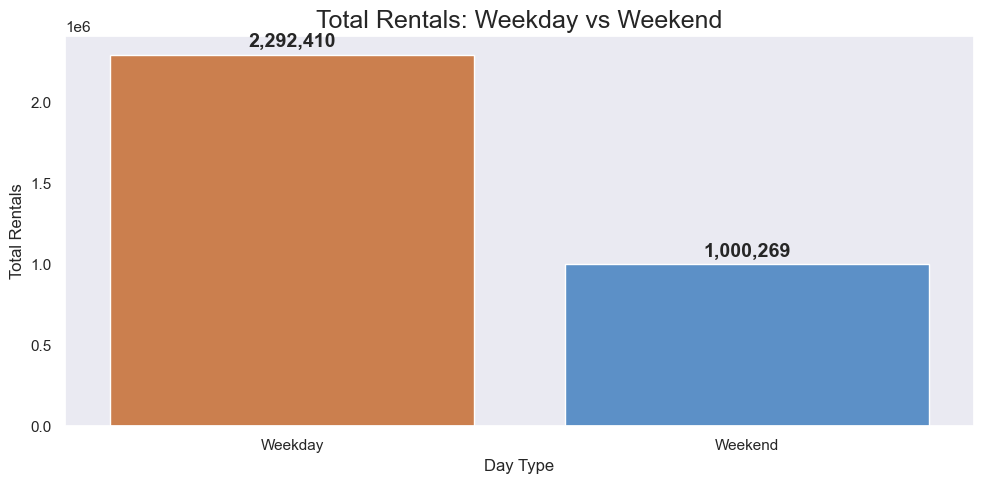

In [179]:
labels = ['Weekday', 'Weekend']
counts = [
    hour_df[hour_df['is_workingday'] == 'Weekday']['cnt'].sum(),
    hour_df[hour_df['is_workingday'] == 'Weekend']['cnt'].sum()
]
colors = get_bar_colors(counts)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=labels, y=counts, palette=colors)
add_bar_annotations(ax, counts, fontsize=14)

plt.title('Total Rentals: Weekday vs Weekend', fontsize=18)
plt.xlabel('Day Type')
plt.ylabel('Total Rentals')
plt.tight_layout()
plt.show()

### Question 4: How does rental behavior differ across seasons?

C:\Users\slyth\AppData\Local\Temp\ipykernel_12824\2195555362.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=colors)


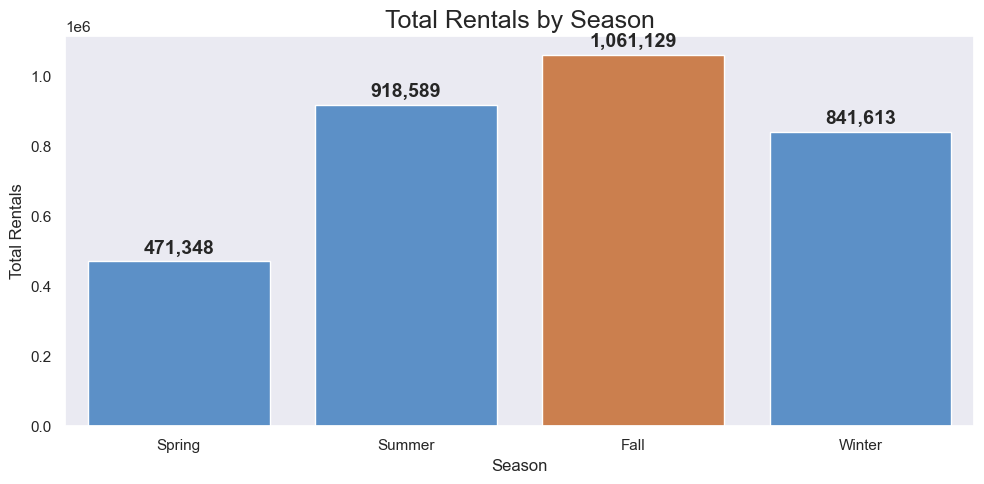

In [180]:
labels = ['Spring', 'Summer', 'Fall', 'Winter']
counts = [
    hour_df[hour_df['season_category'] == 'Spring']['cnt'].sum(),
    hour_df[hour_df['season_category'] == 'Summer']['cnt'].sum(),
    hour_df[hour_df['season_category'] == 'Fall']['cnt'].sum(),
    hour_df[hour_df['season_category'] == 'Winter']['cnt'].sum()
]
colors = get_bar_colors(counts)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=labels, y=counts, palette=colors)
add_bar_annotations(ax, counts, fontsize=14)

plt.title('Total Rentals by Season', fontsize=18)
plt.xlabel('Season')
plt.ylabel('Total Rentals')
plt.tight_layout()
plt.show()

**Insight:** Fall records the highest total rentals (1,061,129), followed by Summer (918,589), Winter (841,163), and Spring (471,348). Users strongly prefer mild, comfortable weather.

### Advanced Analysis: Effect of Weather Condition and Temperature on Rental Behavior

Customer segmentation based on weather and temperature (without machine learning).

C:\Users\slyth\AppData\Local\Temp\ipykernel_12824\264741879.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=colors)


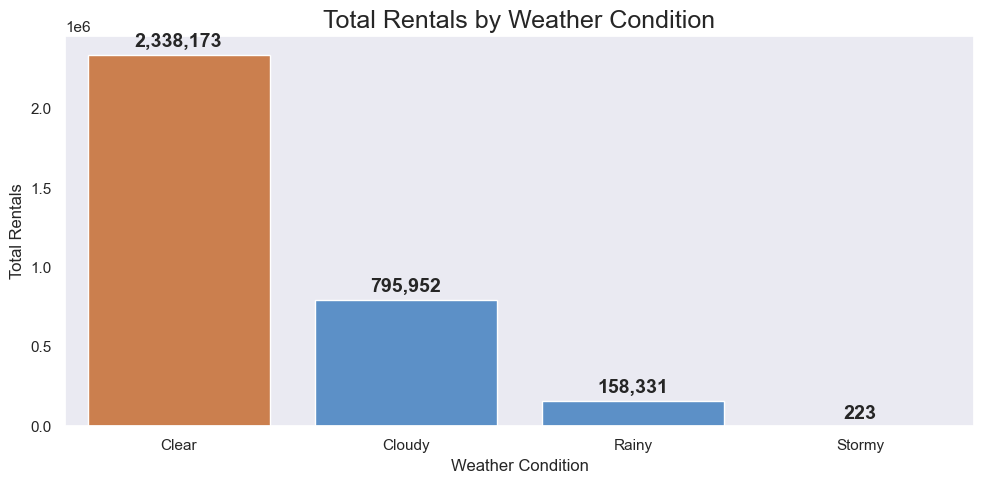

In [181]:
labels = ['Clear', 'Cloudy', 'Rainy', 'Stormy']
counts = [
    hour_df[hour_df['weathersit'] == 1]['cnt'].sum(),
    hour_df[hour_df['weathersit'] == 2]['cnt'].sum(),
    hour_df[hour_df['weathersit'] == 3]['cnt'].sum(),
    hour_df[hour_df['weathersit'] == 4]['cnt'].sum()
]
colors = get_bar_colors(counts)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=labels, y=counts, palette=colors)
add_bar_annotations(ax, counts, fontsize=14)

plt.title('Total Rentals by Weather Condition', fontsize=18)
plt.xlabel('Weather Condition')
plt.ylabel('Total Rentals')
plt.tight_layout()
plt.show()

**Insight:** Weather has a strong impact on rental volume. Clear weather drives the majority of rentals (2,338,173), while rainy and stormy conditions result in near-zero demand.

C:\Users\slyth\AppData\Local\Temp\ipykernel_12824\1181213763.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=counts, palette=colors)


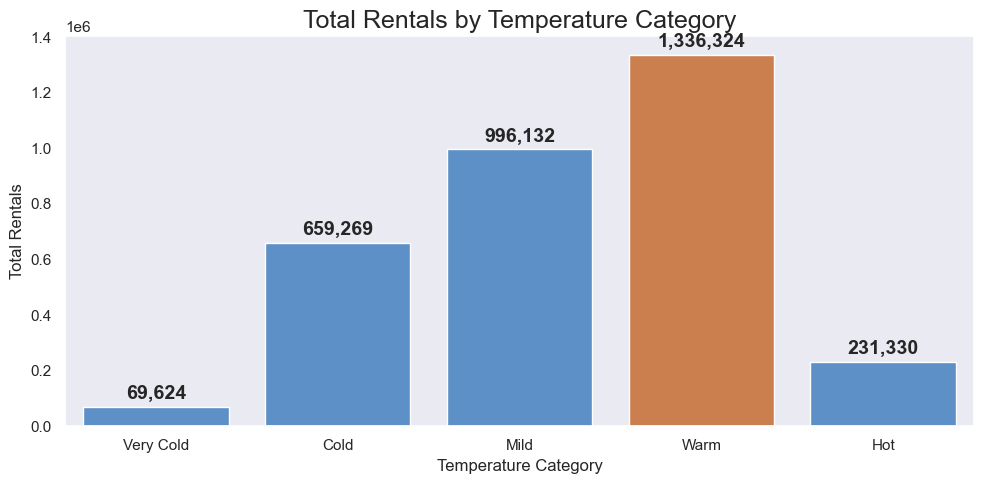

In [182]:
labels = ['Very Cold', 'Cold', 'Mild', 'Warm', 'Hot']
counts = [
    hour_df[hour_df['temp_category'] == 'Very Cold']['cnt'].sum(),
    hour_df[hour_df['temp_category'] == 'Cold']['cnt'].sum(),
    hour_df[hour_df['temp_category'] == 'Mild']['cnt'].sum(),
    hour_df[hour_df['temp_category'] == 'Warm']['cnt'].sum(),
    hour_df[hour_df['temp_category'] == 'Hot']['cnt'].sum()
]
colors = get_bar_colors(counts)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=labels, y=counts, palette=colors)
add_bar_annotations(ax, counts, fontsize=14)

plt.title('Total Rentals by Temperature Category', fontsize=18)
plt.xlabel('Temperature Category')
plt.ylabel('Total Rentals')
plt.tight_layout()
plt.show()

**Insight:** Rentals peak at warm temperatures (1,336,324) and drop significantly at extremes — both very cold (69,624) and hot (231,330) conditions discourage usage.

### Advanced Analysis 2: Peak Hour & Time Segment Analysis

Clustering hourly data into time segments to uncover commuter vs. leisure usage patterns.

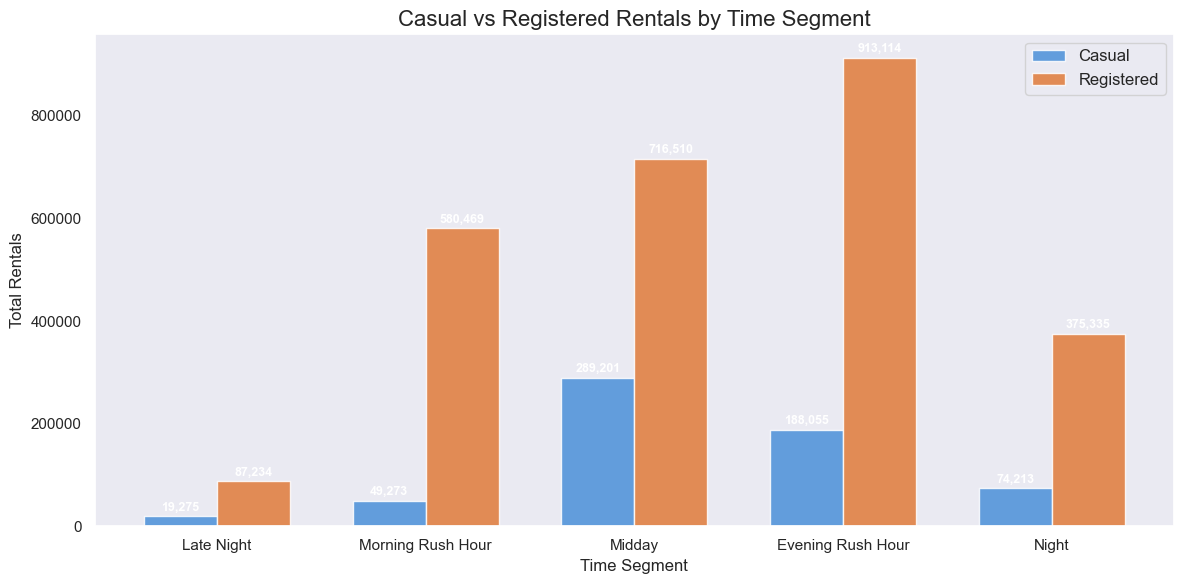

In [183]:
seg_summary = hour_df.groupby('time_segment').agg({'casual': 'sum', 'registered': 'sum'}).reindex(TIME_ORDER)

x      = range(len(TIME_ORDER))
width  = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars_c = ax.bar([i - width/2 for i in x], seg_summary['casual'],     width, label='Casual',     color=BASE_COLOR,      alpha=0.85)
bars_r = ax.bar([i + width/2 for i in x], seg_summary['registered'], width, label='Registered', color=HIGHLIGHT_COLOR, alpha=0.85)

# Annotations
for bar in bars_c:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')
for bar in bars_r:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9, color='white', fontweight='bold')

ax.set_title('Casual vs Registered Rentals by Time Segment', fontsize=16)
ax.set_xlabel('Time Segment')
ax.set_ylabel('Total Rentals')
ax.set_xticks(list(x))
ax.set_xticklabels(TIME_ORDER, fontsize=11)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

**Insight:** Registered users dominate all time segments — especially during rush hours. Casual users are more evenly distributed, peaking during Midday and Evening Rush Hour, which aligns with leisure and recreational riding patterns.

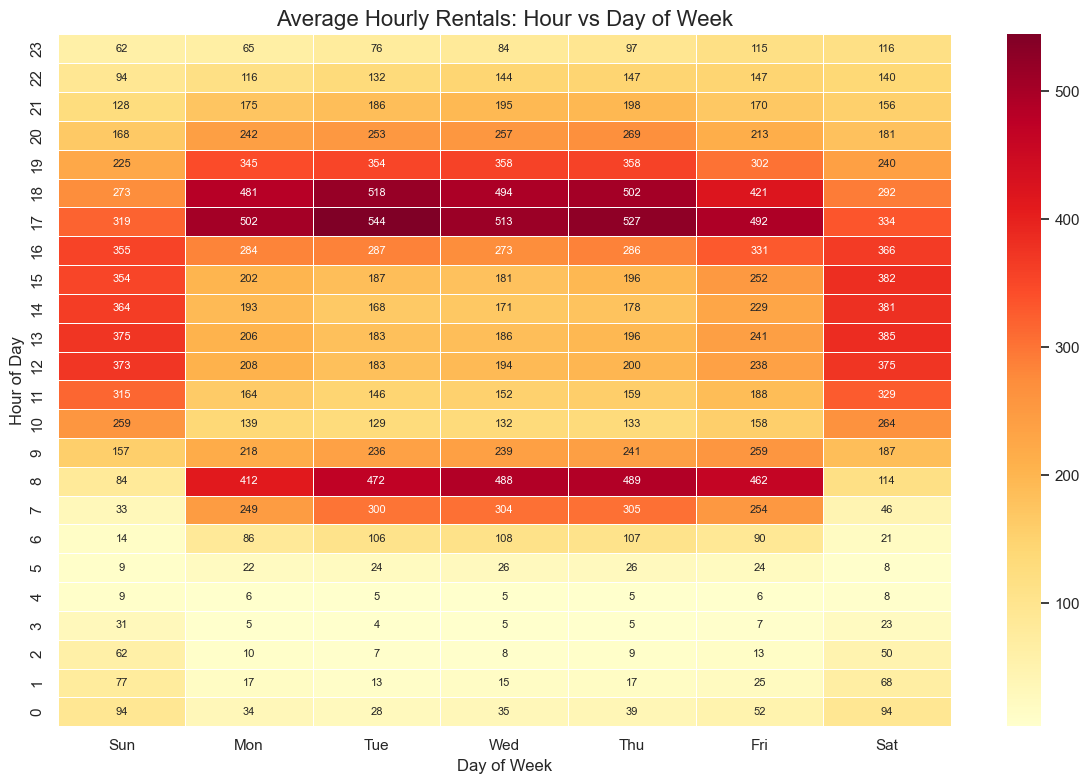

In [184]:
DAY_LABELS = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']

pivot_heatmap = hour_df.pivot_table(
    values='cnt', index='hr', columns='weekday', aggfunc='mean'
).rename(columns=dict(enumerate(DAY_LABELS)))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    pivot_heatmap,
    cmap='YlOrRd',
    linewidths=0.5,
    annot=True, fmt='.0f', annot_kws={'size': 8},
    ax=ax
)
ax.set_title('Average Hourly Rentals: Hour vs Day of Week', fontsize=16)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Hour of Day')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Insight:** The heatmap clearly reveals two distinct patterns:
- **Weekdays (Mon–Fri):** A bimodal pattern with sharp peaks at 08:00 and 17:00–18:00 — classic commuter behavior.
- **Weekends (Sat–Sun):** A broad, gradual peak between 11:00–15:00 — consistent with leisure riding.
- The busiest single slots are Friday and Thursday evenings at 17:00–18:00.

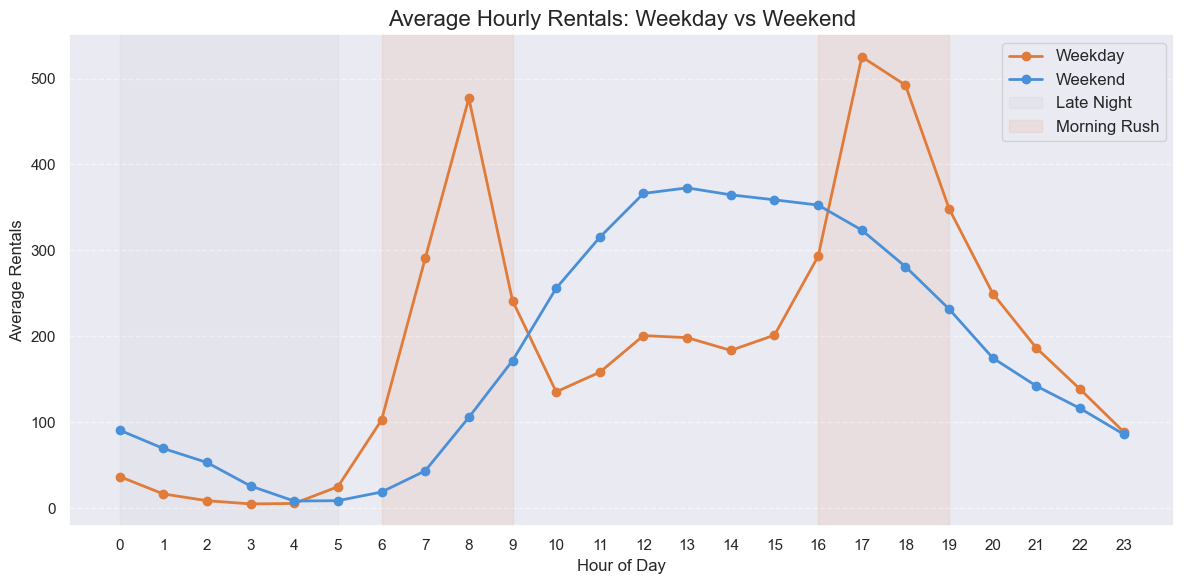

In [185]:
avg_hour_day = hour_df.groupby(['hr', 'is_workingday'])['cnt'].mean().reset_index()

weekday_line = avg_hour_day[avg_hour_day['is_workingday'] == 'Weekday']
weekend_line = avg_hour_day[avg_hour_day['is_workingday'] == 'Weekend']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(weekday_line['hr'], weekday_line['cnt'], marker='o', linewidth=2,
        color=HIGHLIGHT_COLOR, label='Weekday')
ax.plot(weekend_line['hr'], weekend_line['cnt'], marker='o', linewidth=2,
        color=BASE_COLOR,      label='Weekend')

# Shade time segments
ax.axvspan(0,  5,  alpha=0.05, color='gray',  label='Late Night')
ax.axvspan(6,  9,  alpha=0.10, color=HIGHLIGHT_COLOR, label='Morning Rush')
ax.axvspan(16, 19, alpha=0.10, color=HIGHLIGHT_COLOR)

ax.set_title('Average Hourly Rentals: Weekday vs Weekend', fontsize=16)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Average Rentals')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Insight:** The line chart makes the contrast unmistakable:
- **Weekday** rentals spike sharply at 08:00 and 17:00–18:00 (shaded regions), confirming commuter usage.
- **Weekend** rentals form a smooth, single-peak curve centered around noon.
- The company should ensure maximum fleet availability during weekday rush hours and midday on weekends.

### Advanced Analysis 3: Temporal RFM Segmentation

Adapting the RFM framework to temporal data: each **day** is treated as a unit of analysis, scored on three dimensions without any machine learning algorithms.

| Dimension | Definition | Score |
|-----------|------------|-------|
| **R — Recency** | How recently the day occurred (more recent = higher score) | 1–3 |
| **F — Frequency** | Monthly total rentals that month (higher = higher score) | 1–3 |
| **M — Magnitude** | Daily rental volume: Low / Medium / High (33rd & 66th percentile) | 1–3 |

In [186]:
# ── Build full RFM scores ──────────────────────────────────────────────────

# R: Recency — days since each day relative to the last day in dataset
max_date = daily_df['dteday'].max()
daily_df['recency_days'] = (max_date - daily_df['dteday']).dt.days
daily_df['R'] = pd.qcut(daily_df['recency_days'], q=3, labels=[3, 2, 1]).astype(int)

# F: Frequency — monthly total rentals as proxy for activity level
daily_df['monthly_total'] = daily_df.groupby(['yr', 'mnth'])['cnt'].transform('sum')
daily_df['F'] = pd.qcut(
    daily_df['monthly_total'], q=3, labels=[1, 2, 3], duplicates='drop'
).astype(int)

# M: Magnitude — daily volume segment (already computed)
daily_df['M'] = pd.cut(
    daily_df['cnt'],
    bins=[-float('inf'), p33, p66, float('inf')],
    labels=[1, 2, 3]
).astype(int)

# RFM Score (3–9) and Segment label
daily_df['RFM_Score'] = daily_df['R'] + daily_df['F'] + daily_df['M']

def rfm_segment(score):
    if score >= 8:   return 'Champions'
    elif score >= 6: return 'Loyal Days'
    elif score >= 4: return 'Potential'
    else:            return 'Low Activity'

daily_df['RFM_Segment'] = daily_df['RFM_Score'].apply(rfm_segment)

SEG_ORDER = ['Champions', 'Loyal Days', 'Potential', 'Low Activity']
SEG_COLORS = ['#E07B39', '#4A90D9', '#7DB87D', '#B0B0B0']

print('RFM Segment distribution:')
display(daily_df['RFM_Segment'].value_counts())

RFM Segment distribution:


RFM_Segment
Potential       285
Champions       230
Low Activity    109
Loyal Days      107
Name: count, dtype: int64

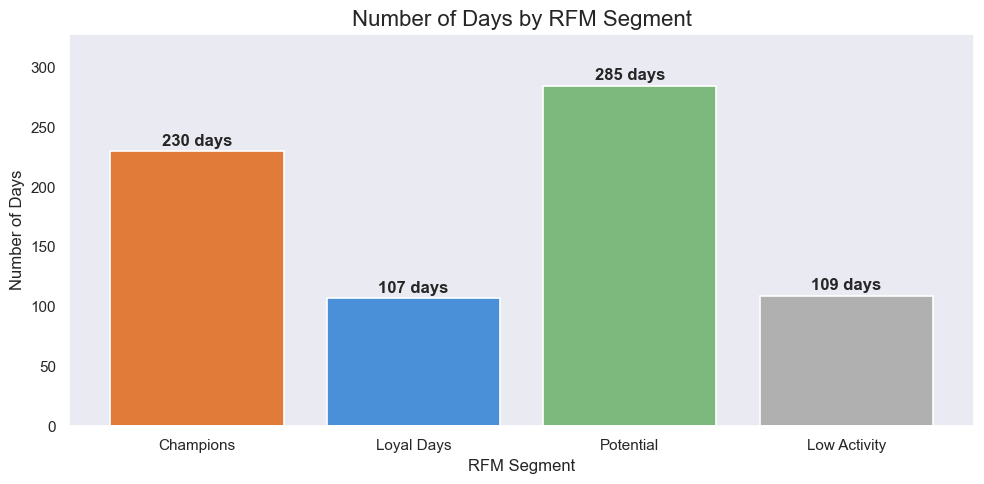

In [187]:
# Chart 1: Number of days per RFM Segment
seg_counts = daily_df['RFM_Segment'].value_counts().reindex(SEG_ORDER).fillna(0)
colors_seg = SEG_COLORS

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(SEG_ORDER, seg_counts.values, color=colors_seg, edgecolor='white', linewidth=1.2)
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{int(val)} days', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Number of Days by RFM Segment', fontsize=16)
ax.set_xlabel('RFM Segment')
ax.set_ylabel('Number of Days')
ax.set_ylim(0, seg_counts.max() * 1.15)
plt.tight_layout()
plt.show()

**Insight:** The majority of days fall in 'Loyal Days' and 'Potential' — indicating a dataset with solid mid-range performance days. 'Champions' represent peak periods (high recency, high frequency, high volume) while 'Low Activity' days are mostly older, off-season, low-volume periods.

RFM Segment Characteristics:


,Days,Avg_Total,Avg_Casual,Avg_Registered,Avg_RFM_Score
RFM_Segment,,,,,
Champions,230,6645,1306,5339,9
Loyal Days,107,4531,944,3587,6
Potential,285,3792,652,3140,5
Low Activity,109,1825,303,1522,3


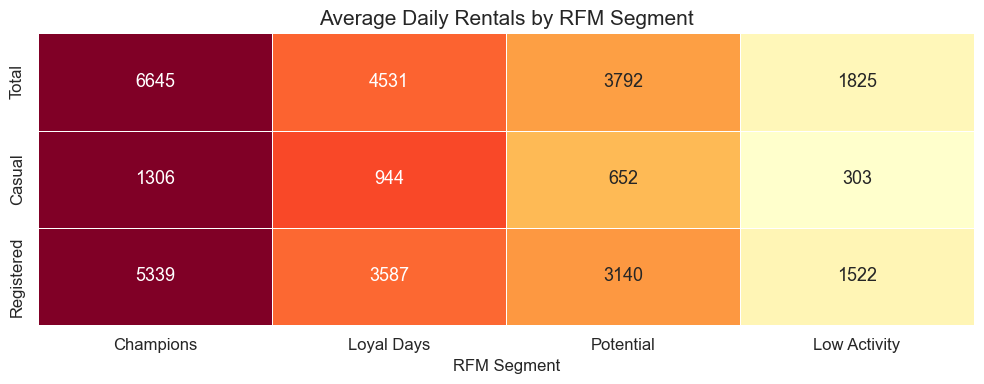

In [188]:
# Chart 2: Average rentals per segment (casual vs registered vs total)
seg_stats = daily_df.groupby('RFM_Segment').agg(
    Days=('cnt', 'count'),
    Avg_Total=('cnt', 'mean'),
    Avg_Casual=('casual', 'mean'),
    Avg_Registered=('registered', 'mean'),
    Avg_RFM_Score=('RFM_Score', 'mean')
).reindex(SEG_ORDER).round(0).astype(int)

print('RFM Segment Characteristics:')
display(seg_stats)

# Heatmap of normalized metrics per segment
heatmap_data = seg_stats[['Avg_Total', 'Avg_Casual', 'Avg_Registered']].T
heatmap_norm = heatmap_data.div(heatmap_data.max(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(
    heatmap_norm,
    annot=heatmap_data.values, fmt='g', annot_kws={'size': 13},
    cmap='YlOrRd', linewidths=0.5,
    xticklabels=SEG_ORDER,
    yticklabels=['Total', 'Casual', 'Registered'],
    ax=ax, cbar=False
)
ax.set_title('Average Daily Rentals by RFM Segment', fontsize=15)
ax.set_xlabel('RFM Segment')
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)
plt.tight_layout()
plt.show()

**Insight:** There's a clear, consistent gap between segments. 'Champions' days average roughly 2–3× more rentals than 'Low Activity' days. Registered users show a steeper gradient across segments than casual users — suggesting registered demand is more elastic to overall conditions (season, weather, recency).

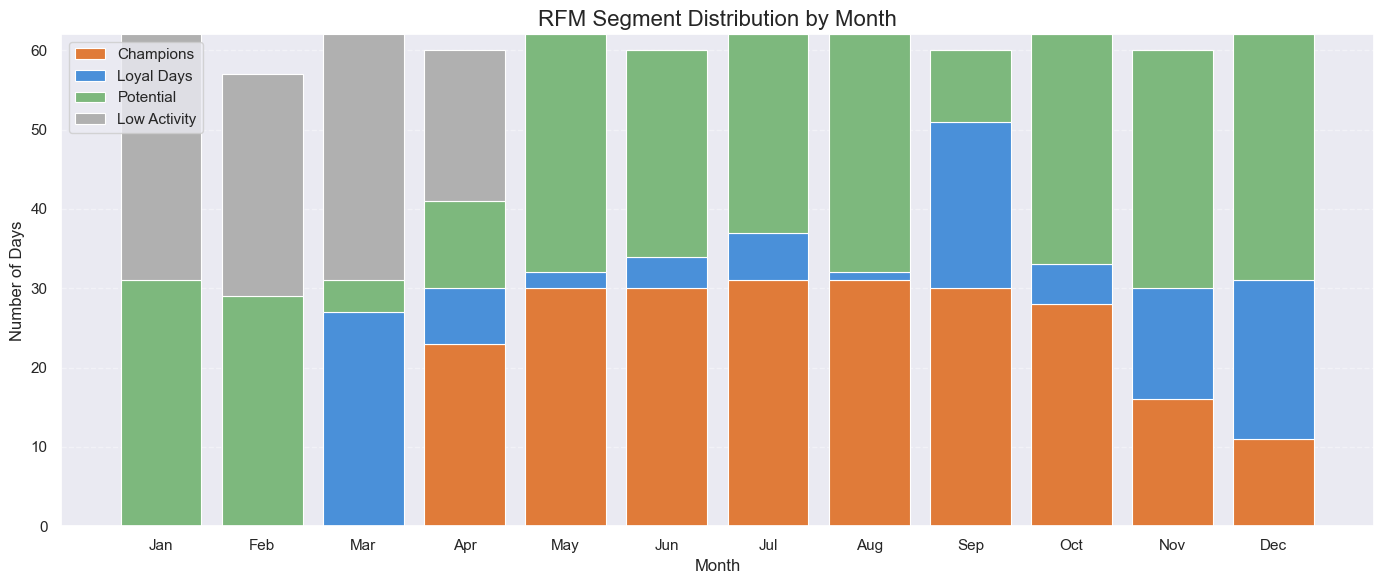

In [189]:
# Chart 3: RFM Segment composition by month
month_seg = daily_df.groupby(['mnth', 'RFM_Segment']).size().unstack(fill_value=0)
month_seg = month_seg.reindex(columns=SEG_ORDER, fill_value=0)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(14, 6))
bottom = [0] * len(month_seg)
for seg, color in zip(SEG_ORDER, SEG_COLORS):
    vals = month_seg[seg].values
    ax.bar(month_seg.index, vals, bottom=bottom,
           label=seg, color=color, edgecolor='white', linewidth=0.8)
    bottom = [b + v for b, v in zip(bottom, vals)]

ax.set_title('RFM Segment Distribution by Month', fontsize=16)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Days')
ax.set_xticks(month_seg.index)
ax.set_xticklabels(month_labels, fontsize=11)
ax.legend(loc='upper left', fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Insight:** Champion and Loyal Days concentrate in mid-year months (May–October), aligning with the Fall/Summer peak observed earlier. January and February are dominated by Low Activity and Potential days — consistent with low-season winter patterns. This confirms that the RFM segmentation aligns well with the known seasonal structure of the dataset.

**Business Recommendation:**
- **Champions months (Aug–Oct):** Maximize fleet availability and introduce premium services.
- **Low Activity months (Jan–Feb):** Use targeted discounts or loyalty incentives to convert Potential days into Loyal Days.
- **Registered users** are the primary driver of Champion-day performance — retention strategies for this group will have the highest ROI.

## Conclusion

**Conclusion 1 — How has bike rental performance trended over time?**

Rental volumes are highly seasonal and show strong year-over-year growth. In 2011, the peak month was June (38,189 rentals), while in 2012 it surged to September (218,573 rentals) — a nearly 6× increase. Declines consistently occur in winter and early spring. The company should develop season-aware marketing strategies and prepare fleet capacity ahead of peak months.

---

**Conclusion 2 — How do casual and registered users compare?**

Registered users (2,672,662) dominate over casual users (620,017), confirming a strong loyal customer base. The company should maintain and grow this registered user base through loyalty programs, while incentivizing casual users to register via special membership offers.

---

**Conclusion 3 — How does rental behavior differ between weekdays and weekends?**

Rentals are consistently higher on weekdays (2011: 613,430 / 2012: 1,436,146) than weekends (2011: 386,839 / 2012: 856,264). This strongly suggests that a large proportion of users rely on bike-sharing for their daily commute. The company can optimize fleet availability on weekdays and run promotions to boost weekend demand.

---

**Conclusion 4 — How does rental behavior differ across seasons?**

Season has a major influence on rental volume. Fall is the most popular season (1,061,129 rentals), followed by Summer (918,589) and Winter (841,163). Spring has the lowest demand (471,348). Users clearly prefer mild, comfortable temperatures. Fleet management and marketing efforts should be aligned with this seasonal pattern.

---

**Conclusion — Advanced Analysis: Weather and Temperature**

Weather and temperature are strong predictors of rental behavior. The vast majority of rentals occur during clear weather (2,338,173) and warm-to-mild temperatures (Warm: 1,336,324 / Mild: 996,132). Rentals drop sharply in rain (158,331) and are almost non-existent during storms (223). The company should monitor real-time weather data to dynamically adjust fleet distribution and consider weather-based promotions to sustain demand during off-peak conditions.


---

**Conclusion 5 — What are the peak rental hours, and how do they differ between weekdays and weekends?**

Hourly patterns reveal two fundamentally different usage profiles. On weekdays, rentals spike sharply at 08:00 and 17:00–18:00 — a classic bimodal commuter pattern driven predominantly by registered users. On weekends, rentals rise gradually to a broad midday peak (11:00–15:00), reflecting recreational and leisure use with relatively higher casual user participation. Evening Rush Hour (16:00–19:00) is the single most active time segment overall. These findings suggest the company should prioritize fleet availability during weekday rush hours and midday on weekends, and could offer time-based promotions (e.g., off-peak discounts on weekday middays) to balance demand distribution.


---

**Conclusion 6 — How can days be segmented by rental volume? (Temporal RFM)**

Applying a temporal RFM framework to daily-aggregated data reveals four distinct day archetypes. Champion days — characterized by high recency, high monthly frequency, and high daily volume — cluster heavily in August through October, confirming the seasonal peak. Low Activity days dominate January and February. Registered users are the primary differentiator between segments, showing a steeper volume gradient than casual users. The company should allocate resources (fleet, staff, promotions) in line with predicted RFM segments, and run targeted re-engagement campaigns during historically Low Activity months to elevate them toward Potential or Loyal Days.

In [190]:
# Final check — verify all new columns
hour_df[['dteday', 'season_category', 'is_workingday', 'temp_category', 'time_segment', 'cnt']].head(10)

,dteday,season_category,is_workingday,temp_category,time_segment,cnt
0,2011-01-01,Spring,Weekend,Cold,Late Night,16
1,2011-01-01,Spring,Weekend,Cold,Late Night,40
2,2011-01-01,Spring,Weekend,Cold,Late Night,32
3,2011-01-01,Spring,Weekend,Cold,Late Night,13
4,2011-01-01,Spring,Weekend,Cold,Late Night,1
5,2011-01-01,Spring,Weekend,Cold,Late Night,1
6,2011-01-01,Spring,Weekend,Cold,Morning Rush Hour,2
7,2011-01-01,Spring,Weekend,Very Cold,Morning Rush Hour,3
8,2011-01-01,Spring,Weekend,Cold,Morning Rush Hour,8
9,2011-01-01,Spring,Weekend,Cold,Morning Rush Hour,14


In [191]:
# Save cleaned dataset
hour_df.to_csv("bike_sharing_clean.csv", index=False)
print("Dataset saved as bike_sharing_cleaned.csv")

Dataset saved as bike_sharing_cleaned.csv
